# Spectrum of post flare loop

In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import numpy as np

#%matplotlib inline
#%matplotlib qt
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
%load_ext autoreload
%autoreload 2

from spectra_src.ImportAll import *
import warnings
warnings.simplefilter('ignore', UserWarning)
warnings.simplefilter('ignore', DeprecationWarning)

from spectra_src.Struct import Atom, Atmosphere, Radiation
from spectra_src.Atomic import Collision, SEsolver, ContinuumOpacity, BasicP
from spectra_src.Util.HelpUtil import help_
from spectra_src.Visual import Plotting  #, Grotrian
from spectra_src.Atomic import LTELib
from spectra_src.Function.SEquil import SELib
from spectra_src.Atomic import Hydrogen
from spectra_src.Util.AtomUtils.AtomInfo import level_info, extract_lprof, each_prof, line_list
from spectra_src import Constants as Cst
from spectra_src.Function.SlabModel import CloudModel
import sys

/tmp/ipykernel_1720/2314531484.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import display, HTML


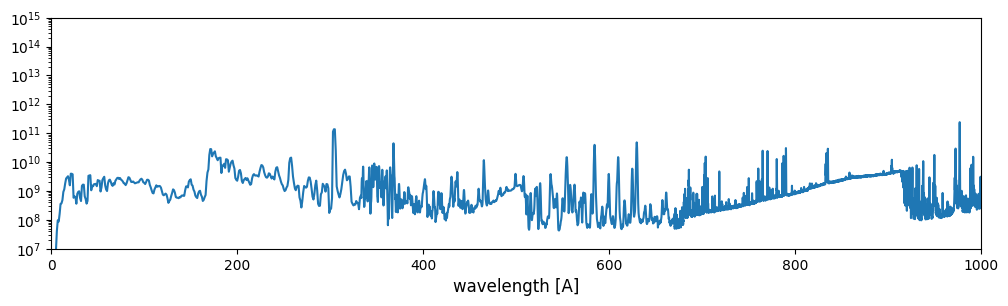

In [2]:
# Atomic model
import os

conf_path = os.path.join( CFG._ROOT_DIR, "data/conf/H.conf" )  ; H_nam ='H'
atom_H, wMesh_H, path_dict_H = Atom.init_Atom_(conf_path , is_hydrogen=True)
conf_path = os.path.join( CFG._ROOT_DIR, "data/conf/He.conf" ) ; He_nam ='He'
atom_He, wMesh_He, path_dict_He = Atom.init_Atom_(conf_path , is_hydrogen=False)
conf_path = os.path.join( CFG._ROOT_DIR, "data/conf/Ca_I-II-III_250421.conf" ) ; Ca_nam ='Ca_I-II-III' 
#conf_path = os.path.join( CFG._ROOT_DIR, "data/conf/Ca_II.conf" ) ; Ca_nam ='Ca_II'
atom_Ca, wMesh_Ca, path_dict_ca = Atom.init_Atom_(conf_path , is_hydrogen=False)

#  prepare solar radiation spectrum
import copy

atmos = Atmosphere.Atmosphere0D(Nh=1.E12, Ne=1.E11, Te=7.E3, Vd=0., Vt=5.E5)
solar_spec_H  = Radiation.init_Radiation_(atmos, wMesh_H)
solar_spec_He = Radiation.init_Radiation_(atmos, wMesh_He)
solar_spec_Ca = Radiation.init_Radiation_(atmos, wMesh_Ca)

wls = solar_spec_H.backRad[0,:]*1E8         
wls_air = BasicP.vacuum_to_air_(wls,'AA')   # wavelength in air of background solar spectrum [A]
Isolar = solar_spec_H.backRad[1,:].copy()   # background solar spectrum intensity    "    [erg/cm^3/s/str]

#  for photo-excitation, mean intensity gets half of the backgroud solar spectrum
solar_spec_H.backRad[1,:] *= 0.5            # solar spectrum mean intensity    "    [erg/cm^3/s/str]
solar_spec_H.PI_intensity[:,:] *= 0.5       # solar spectrum mean intensity    "    [erg/cm^3/s/str]
solar_spec_He.backRad[1,:] *= 0.5           # solar spectrum mean intensity    "    [erg/cm^3/s/str]
solar_spec_He.PI_intensity[:,:] *= 0.5      # solar spectrum mean intensity    "    [erg/cm^3/s/str]
solar_spec_Ca.backRad[1,:] *= 0.5           # solar spectrum mean intensity    "    [erg/cm^3/s/str]
solar_spec_Ca.PI_intensity[:,:] *= 0.5      # solar spectrum mean intensity    "    [erg/cm^3/s/str]

solar_spec_H0 = copy.deepcopy(solar_spec_H)
solar_spec_He0 = copy.deepcopy(solar_spec_He)
solar_spec_Ca0 = copy.deepcopy(solar_spec_Ca)


fig, ax = plt.subplots(1,1, figsize=(12,3), dpi=100)
ax.plot(wls_air, Isolar)
#ax.set_yscale('log')
ax.set_xlim(0, 1000)
#ax.set_xlim(10820, 10840) ; ax.set_ylim(0,1.2e14)
ax.set_yscale("log") ; ax.set_ylim(1e7,1e15)
ax.set_xlabel("wavelength [A]", fontsize=12)
plt.show()

In [3]:
def enhance_EUV(solar_spec,wMesh,ampl,wleuv=504.):  # Enhance EUV for He 1083nm
    
    # amp_euv = 10.  #  enhance EUV radiation for He 10830

    solar_spec2 = copy.deepcopy(solar_spec)
    wleuv *= 1e-8
    print("wleuv=",wleuv)

    ii = np.where(solar_spec2.backRad[0,:] < wleuv)[0]
    solar_spec2.backRad[1,ii] *= ampl
    ii = np.where(wMesh.Cont_mesh.reshape(-1) < wleuv)[0]
    solar_spec2.PI_intensity.reshape(-1)[ii] *= ampl
    
    return solar_spec2
    

In [22]:
#    2025.7.16     j.n.     add src_tot for HeI1083nm multiplet
#-------------------------------------------------------------
def extract_line(l, wl, Ic=0.):
#-------------------------------------------------------------
# extract line profile in a wl interval from l-structure
# wl[:]  -- in A 
# Ic  -- background intensity

    nw = wl.size
    profe = np.zeros(nw)
    tau = np.zeros(nw)
    emisivity_tot=0.; absorption_tot=0.

    w0 = l.w0 *1e8
    jj = np.where((w0 > min(wl)) & (w0 < max(wl)))[0]
    if i==2: print(min(wl),max(wl),jj)
    for j in jj:
        idx1 = l.Line_mesh_idxs[j,0] 
        idx2 = l.Line_mesh_idxs[j,1]
        tau1 = np.interp(wl, l.wl_1D[idx1:idx2]*1e8, l.tau_1D[idx1:idx2])
        #prof1 = l.Src[j] * (1.-np.exp(-tau1))
        tau += tau1
        #profe += prof1
        emisivity_tot += l.line_emissivity[j]
        absorption_tot += l.line_absorption[j]
        
    src_tot=emisivity_tot/absorption_tot
    #prof = Ic*np.exp(-tau) + profe
    prof = Ic*np.exp(-tau) + src_tot*(1-np.exp(-tau))
    #sys.exit()
    
    ldat = {
        "intens": prof,
        "tau": tau,
        #"src": max(l.Src[jj]),
        "src": src_tot,
        "nline": jj.size
    }
    
    return ldat
    
def wlarr(wl00,vmax,dv):
# return wl[:] around wl00 in A,  vmax, dv  in km/s

    dw = dv/Cst.c_*wl00*1e5
    wmin = wl00 - dw*vmax/dv
    wmax = wl00 + dw*vmax/dv
    nw = 2*int(vmax/dv) +1
    #nw = int((wmax-wmin)/dw) + 1
    wl = np.linspace(wmin,wmax,nw)
    return wl


dict_keys(['elem', 'wl0', 'wl', 'wl_air', 'Isolar', 'Ic'])
dict_keys(['elem', 'wl0', 'wl', 'wl_air', 'Isolar', 'Ic'])
dict_keys(['elem', 'wl0', 'wl', 'wl_air', 'Isolar', 'Ic'])
dict_keys(['elem', 'wl0', 'wl', 'wl_air', 'Isolar', 'Ic'])


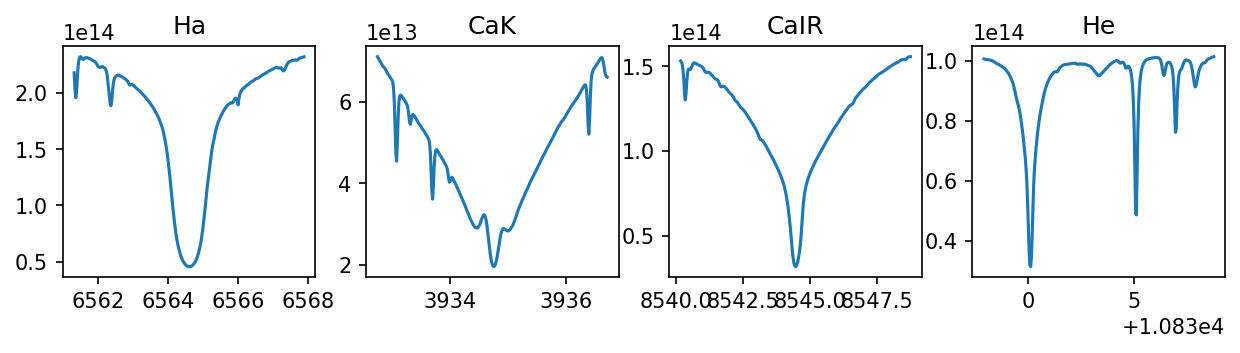

In [13]:
### define lines of interest ###

vmax = 150. ; dv = 1.  # km/s
vc=3.e5
ls = [
    {'elem': 'Ha',  'wl0': 6562.81},
    {'elem':'CaK',  'wl0': 3933.66},
    {'elem':'CaIR',  'wl0': 8542.12},
    {'elem': 'He', 'wl0': 10830.35}
]

nl = len(ls)
for i in range(nl):
    wl_air = wlarr( ls[i]['wl0'], vmax, dv )  # w-array in air centered by the line
    wl = BasicP.air_to_vacuum_(wl_air,'AA') # w-array in vacuum
    Isol = np.interp(wl, wls, Isolar)        # Solar spectrum of the line
    Ic = np.max(Isol)                         # continuum intensity
    ls[i].update({'wl': wl, 'wl_air': wl_air, 'Isolar': Isol, 'Ic': Ic})
    print(ls[i].keys())

### plot a line profile in solar spectrum ###
fig, axs = plt.subplots(1,nl, figsize=(10,2), dpi=150)
for i in range(nl):
    axs[i].plot(ls[i]['wl'],ls[i]['Isolar'])
    ax.set_ylim(0,max(ls[i]["Isolar"])*1.2)
    axs[i].set_title(ls[i]['elem'])


In [14]:
# import CloudModel from spectra_src.Function.SlabModel

Te = 10000.
Nh = 1*1e12
Ne = 2e11
Vd = 0.
Vt = 15e5            #   cm/s
depth = 0.5E3 * 1.E5 #   km *1e5

EUV_ampl = 1   # EUV enhancement for He background
solar_spec_He = enhance_EUV(solar_spec_He0,wMesh_He,EUV_ampl)

slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
SE_H, Rate_H = SELib.cal_SE_with_Ne_Te_(atom_H, slab, wMesh_H, solar_spec_H, None)  #  level populations etc.
lH = CloudModel.SE_to_slab_0D_(atom_H, slab, SE_H, depth=depth)      # hydrogen lines intensity
SE_He, Rate_He = SELib.cal_SE_with_Ne_Te_(atom_He, slab, wMesh_He, solar_spec_He, SE_H.n_SE)  #  level populations etc.
lHe = CloudModel.SE_to_slab_0D_(atom_He, slab, SE_He, depth=depth)      # hydrogen lines intensity
SE_Ca, Rate_Ca = SELib.cal_SE_with_Ne_Te_(atom_Ca, slab, wMesh_Ca, solar_spec_Ca, SE_H.n_SE)  #  level populations etc.
lCa = CloudModel.SE_to_slab_0D_(atom_Ca, slab, SE_Ca, depth=depth)      # hydrogen lines intensity
print(slab)
print(SE_H.Nh)

wleuv= 5.04e-06
Atmosphere0D(Nh=np.float64(1132969375489.2188), Ne=200000000000.0, Te=10000.0, Vd=0.0, Vt=1500000.0, Ti=-1.0, ndim=0, is_uniform=True, Tr=6000.0, use_Tr=False, Pg=0.05, doppler_shift_continuum=False, _coord_type=<E_ATMOSPHERE_COORDINATE_TYPE.POINT: 0>)
1132969375489.2188


8540.183090919858 8548.73348368618 [219]


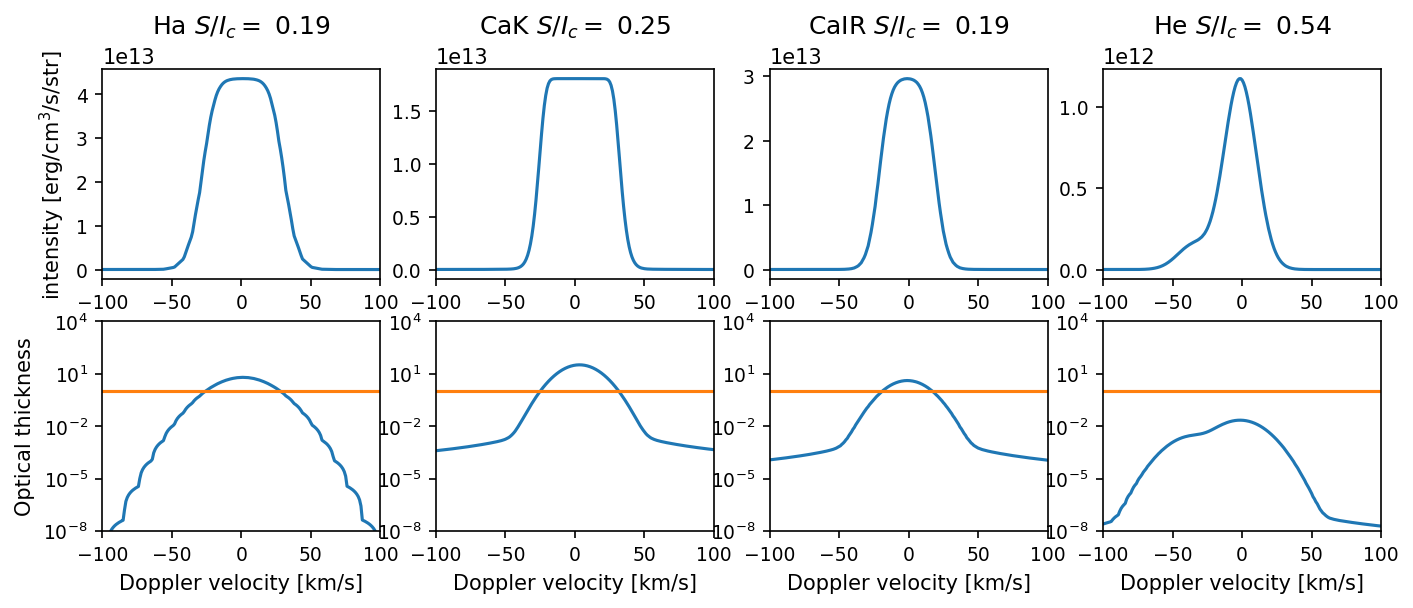

In [23]:
##  plot line profiles with no background
fig, axs = plt.subplots(2,nl, figsize=(11,4), dpi=150)

for i in range(nl):
    if ls[i]['elem'] == 'Ha':
        l_elm = lH
    elif ls[i]['elem'] == 'He':
        l_elm = lHe
    elif ls[i]['elem'] == 'CaK':
        l_elm = lCa
    elif ls[i]['elem'] =='CaIR':
        l_elm = lCa
    l1 = extract_line(l_elm, ls[i]['wl'], Ic=0.)   #  ['intens', 'tau', 'src']
    ls[i].update(l1)
    ax = axs[0,i]
    #ax.plot(ls[i]['wl_air']-ls[i]['wl0'], ls[i]['intens'])
    ax.plot((ls[i]['wl_air']-ls[i]['wl0'])/ls[i]['wl0']*vc, ls[i]['intens'])
    #ax.plot(ls[i]['wl_air'], ls[i]['Isolar'])
    #ax.set_xlabel("Doppler velocity [km/s]", fontsize=10)
    ax.tick_params(axis ='x', labelsize =9)
    ax.tick_params(axis ='y', labelsize =9)
    if i == 0:
        ax.set_ylabel("intensity [erg/cm$^3$/s/str]", fontsize=10)
    ax.set_xlim(-100.,100.)
    #ax.set_ylim(max(ls[i]["intens"])*0.,max(ls[i]["intens"])*0.8)
    ax.set_title(ls[i]['elem']+' '+"$S/I_c=$"+f"{ls[i]['src']/ls[i]['Ic']:5.2F}")
    #axs[i].set_title(ls[i]['elem'])
    
    ax = axs[1,i]
    ax.plot((ls[i]['wl_air']-ls[i]['wl0'])/ls[i]['wl0']*vc, ls[i]['tau'])
    ax.set_yscale('log') 
    ax.set_xlabel("Doppler velocity [km/s]", fontsize=10)
    ax.tick_params(axis ='x', labelsize =9)
    ax.tick_params(axis ='y', labelsize =9)
    ax.set_xlim(-100.,100.)
    ax.plot([-100,100],[1,1])
    ax.autoscale(axis='y')
    ax.set_ylim(1e-8,1e4)
    if i == 0:
        ax.set_ylabel("Optical thickness", fontsize=10)


8540.183090919858 8548.73348368618 [219]


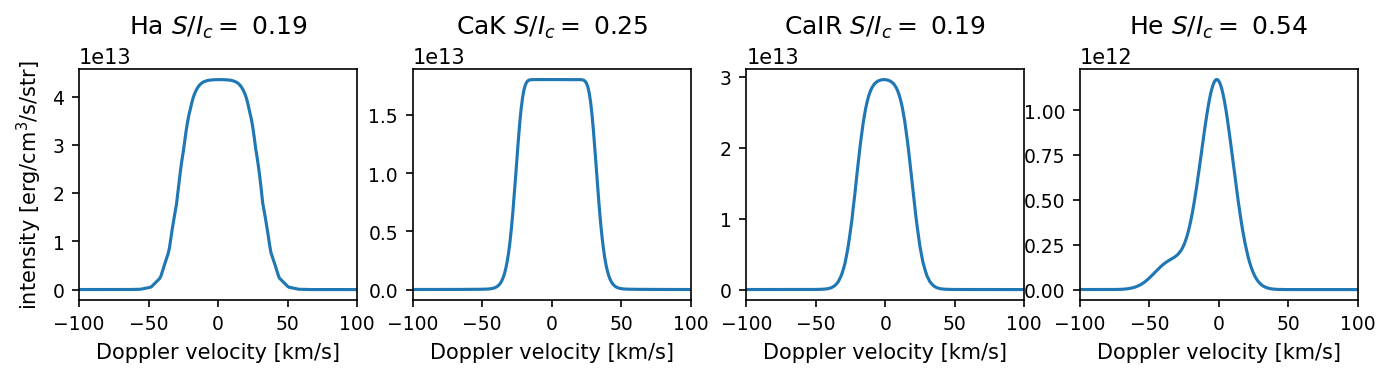

In [24]:
##  plot line profiles with no background
fig, axs = plt.subplots(1,nl, figsize=(11,2), dpi=150)
#print('1lIと0O全角スペース　を表示')
for i in range(nl):
    if ls[i]['elem'] == 'Ha':
        l_elm = lH
    elif ls[i]['elem'] == 'He':
        l_elm = lHe
    elif ls[i]['elem'] == 'CaK':
        l_elm = lCa
    elif ls[i]['elem'] =='CaIR':
        l_elm = lCa
    l1 = extract_line(l_elm, ls[i]['wl'], Ic=0.)   #  ['intens', 'tau', 'src']
    ls[i].update(l1)
    ax = axs[i]
    #ax.plot(ls[i]['wl_air']-ls[i]['wl0'], ls[i]['intens'])
    #ax.plot(ls[i]['wl_air'], ls[i]['Isolar'])
    #ax.set_xlabel("wavelength [A]", fontsize=10)
    ax.plot((ls[i]['wl_air']-ls[i]['wl0'])/ls[i]['wl0']*vc, ls[i]['intens'])
    ax.set_xlabel("Doppler velocity [km/s]", fontsize=10)
    ax.tick_params(axis ='x', labelsize =9)
    ax.tick_params(axis ='y', labelsize =9)
    if i == 0:  ax.set_ylabel("intensity [erg/cm$^3$/s/str]", fontsize=10)
    ax.set_xlim(-100.,100.)
    #ax.set_ylim(max(ls[i]["intens"])*0.,max(ls[i]["intens"])*0.8)
    ax.set_title(ls[i]['elem']+' '+"$S/I_c=$"+f"{ls[i]['src']/ls[i]['Ic']:5.2F}")
    #axs[i].set_title(ls[i]['elem'])


In [25]:
help_(lCa)

------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
------------------------------------------------------------------------------------------
CloudModel_Container
|- w0                      ndarray                              s: (471,)
|- tau_max                 ndarray                              s: (471,)
|- Ibar                    ndarray                              s: (471,)
|- Src                     ndarray                              s: (471,)
|- tau_1D                  ndarray                              s: (20465,)
|- prof_1D                 ndarray                              s: (20465,)
|- wl_1D                   ndarray                              s: (20465,)
|- Line_mesh_idxs          ndarray                              s: (471, 2)
|- line_emissivity         ndarray                              s: (471,)
|- line_absorption         ndarray         

In [26]:
l1['nline']

3